# Retail Sales Dataset — Exploratory Data Analysis

**Objective:** Uncover patterns, customer behaviour trends, and actionable business insights from retail transaction data.

**Tech Stack:** Python, pandas, matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [2]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,345,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,2023-05-16,CUST001,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,11,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
std,288.819436,NaN,NaN,NaN,13.68143,NaN,1.132734,189.681356,559.997632
min,1.000000,NaN,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,NaN,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,NaN,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,NaN,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df["Date"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


In [4]:
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df["Product Category"].unique()


Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


array(['Beauty', 'Clothing', 'Electronics'], dtype=object)

**Observation:** The dataset contains **1,000 transactions** across **9 columns** with **zero missing values** and **zero duplicate rows** — the data is clean and requires no imputation. Columns include transaction metadata (ID, date), customer attributes (ID, gender, age), and purchase details (category, quantity, price, total amount). Note: `Product Category` has only 3 distinct values (Beauty, Clothing, Electronics) — there is no individual product-name column, so "best-selling products" analysis below is done at the category level, supplemented by a price-tier breakdown to add granularity.

# Statistics

In [5]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
desc_stats = df[numerical_cols].describe().T
desc_stats['median'] = df[numerical_cols].median()
desc_stats['mode'] = df[numerical_cols].mode().iloc[0]
desc_stats = desc_stats[['mean', 'median', 'mode', 'std', 'min', 'max']]
desc_stats.round(2)


,mean,median,mode,std,min,max
Age,41.39,42.0,43.0,13.68,18.0,64.0
Quantity,2.51,3.0,4.0,1.13,1.0,4.0
Price per Unit,179.89,50.0,50.0,189.68,25.0,500.0
Total Amount,456.00,135.0,50.0,560.00,25.0,2000.0


Age is fairly symmetric (mean ≈ median, 18–64 range, no major outliers). Quantity is stable and small-range (1–4). Price per Unit and Total Amount are both right-skewed — mean much higher than median, with std almost as large as the mean — meaning a few high-value transactions are pulling the average up. 

## 3. Time Series Analysis: Monthly & Quarterly Sales Trends

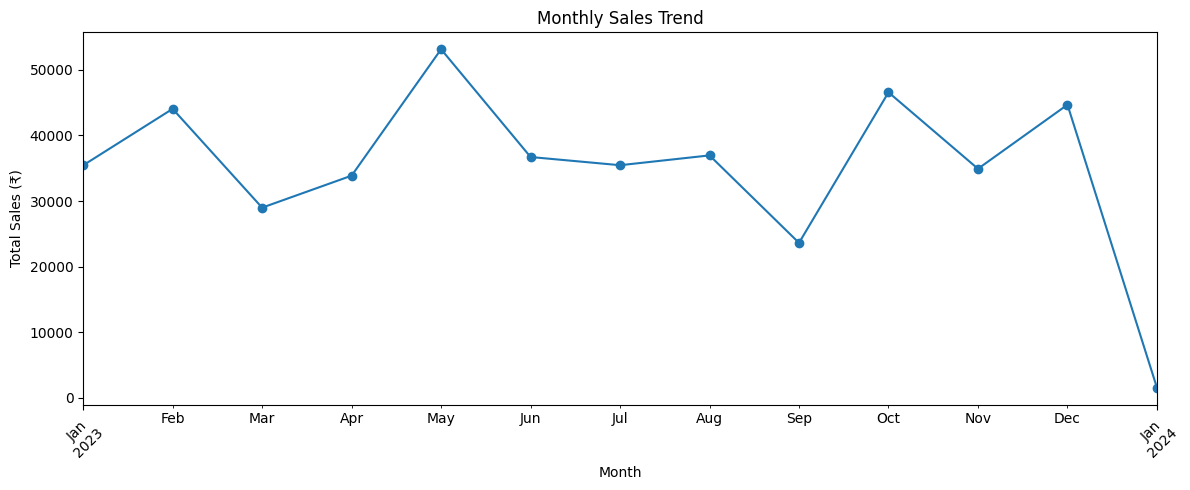

In [6]:
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')
monthly_sales = df.groupby('Month')['Total Amount'].sum()
fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', ax=ax)
ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


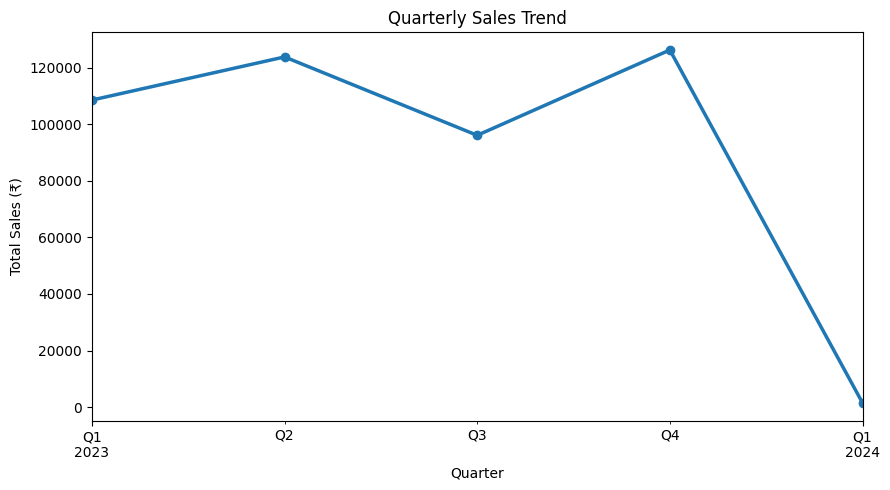

In [7]:
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
fig, ax = plt.subplots(figsize=(9, 5))
quarterly_sales.plot(kind='line', marker='o', ax=ax , linewidth=2.5)
ax.set_title('Quarterly Sales Trend')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales (₹)')
plt.tight_layout()
plt.show()


**Observation:** Monthly sales go up and down with no clear seasonal pattern — a few months are noticeably higher, which could be worth checking against any promotions run then. Since almost all the data is from 2023 (only 2 rows from 2024), the quarterly trend just shows seasonality within 2023, not year-over-year growth.

## 4. Customer Demographics Analysis

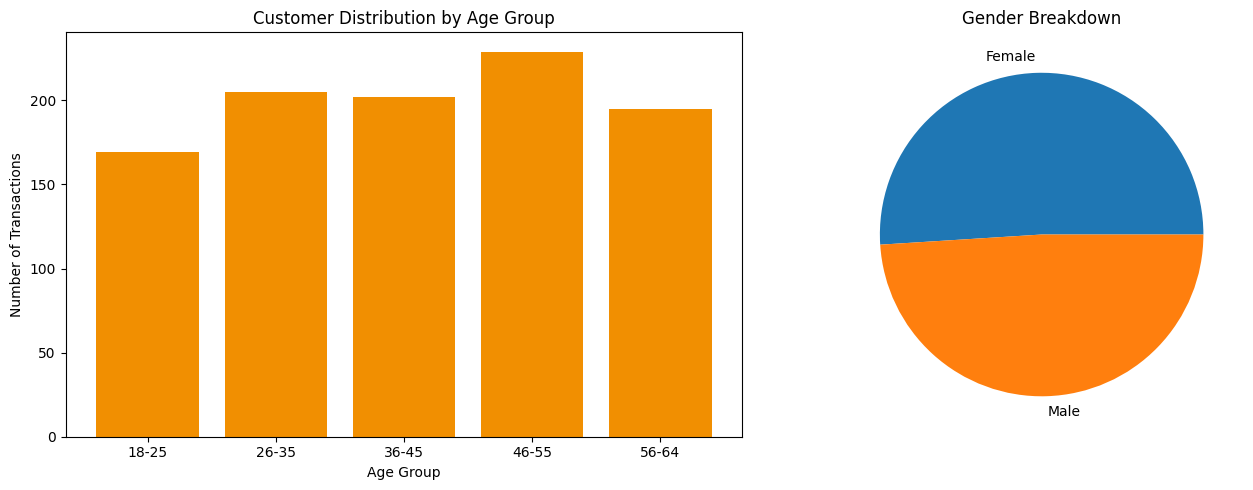

In [8]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
age_counts = df['Age Group'].value_counts().sort_index()
axes[0].bar(age_counts.index.astype(str), age_counts.values, color='#F18F01')
axes[0].set_title('Customer Distribution by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Transactions')
gender_counts = df['Gender'].value_counts()
axes[1].pie(gender_counts.values, labels=gender_counts.index)
axes[1].set_title('Gender Breakdown')
plt.tight_layout()
plt.show()


In [9]:
gender_spend = df.groupby('Gender')['Total Amount'].agg(['sum', 'mean', 'count'])
gender_spend.columns = ['Total Revenue', 'Avg Transaction Value', 'Transaction Count']
gender_spend.round(2)


,Total Revenue,Avg Transaction Value,Transaction Count
Gender,,,
Female,232840,456.55,510
Male,223160,455.43,490


**Observation:** Female and male customers spend almost the same on average per transaction (₹456.55 vs ₹455.43), and transaction counts are close too (510 vs 490). Gender has little effect on spending — total revenue is slightly higher for females mainly because there are more female transactions, not because they spend more per purchase.

## 5. Product Analysis

There's no individual product name column — only 3 broad categories (Beauty, Clothing, Electronics), which isn't enough for a real top-10 product ranking. So this section looks at (a) revenue by category, and (b) category + price combined as a stand-in for "products" to get a top-10 list.


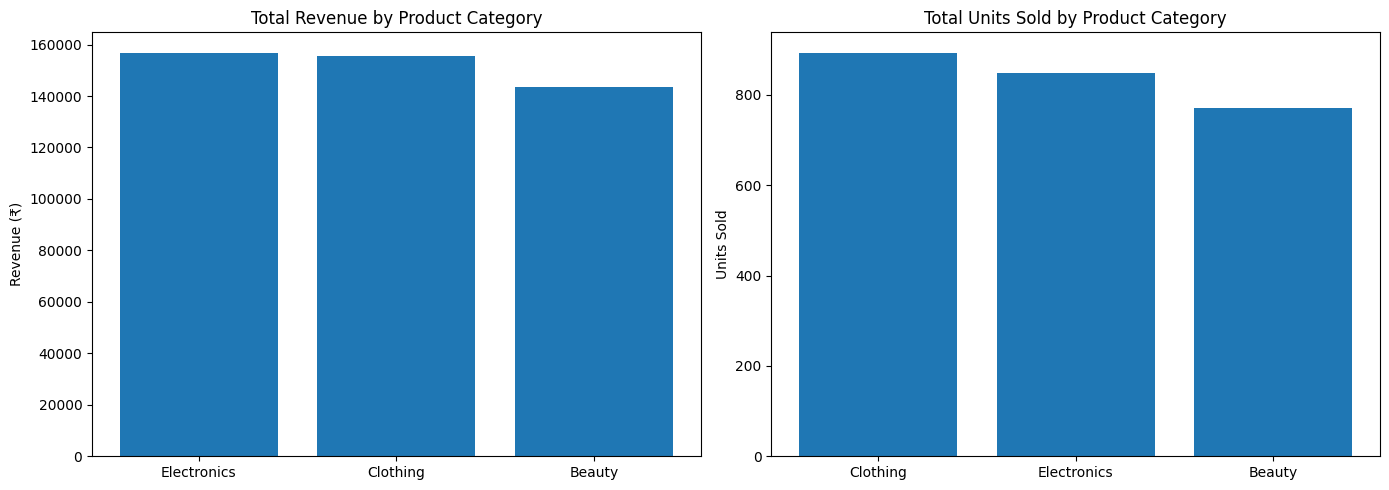

In [10]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(category_revenue.index, category_revenue.values)
axes[0].set_title('Total Revenue by Product Category')
axes[0].set_ylabel('Revenue (₹)')

axes[1].bar(category_qty.index, category_qty.values)
axes[1].set_title('Total Units Sold by Product Category')
axes[1].set_ylabel('Units Sold')

plt.tight_layout()
plt.show()


In [11]:
# Proxy "products" = Category + Price per Unit combination, ranked by total revenue
df['Product Line'] = df['Product Category'] + ' - ₹' + df['Price per Unit'].astype(str)

top_products = (df.groupby('Product Line')
                  .agg(Total_Revenue=('Total Amount', 'sum'),
                       Units_Sold=('Quantity', 'sum'),
                       Transactions=('Transaction ID', 'count'))
                  .sort_values('Total_Revenue', ascending=False)
                  .head(10))
top_products


,Total_Revenue,Units_Sold,Transactions
Product Line,,,
Beauty - ₹500,84500,169,68
Electronics - ₹500,84500,169,67
Clothing - ₹500,78500,157,64
Clothing - ₹300,57900,193,72
Electronics - ₹300,54900,183,72
Beauty - ₹300,42600,142,53
Clothing - ₹50,9450,189,75
Electronics - ₹50,8750,175,69
Beauty - ₹50,8500,170,67


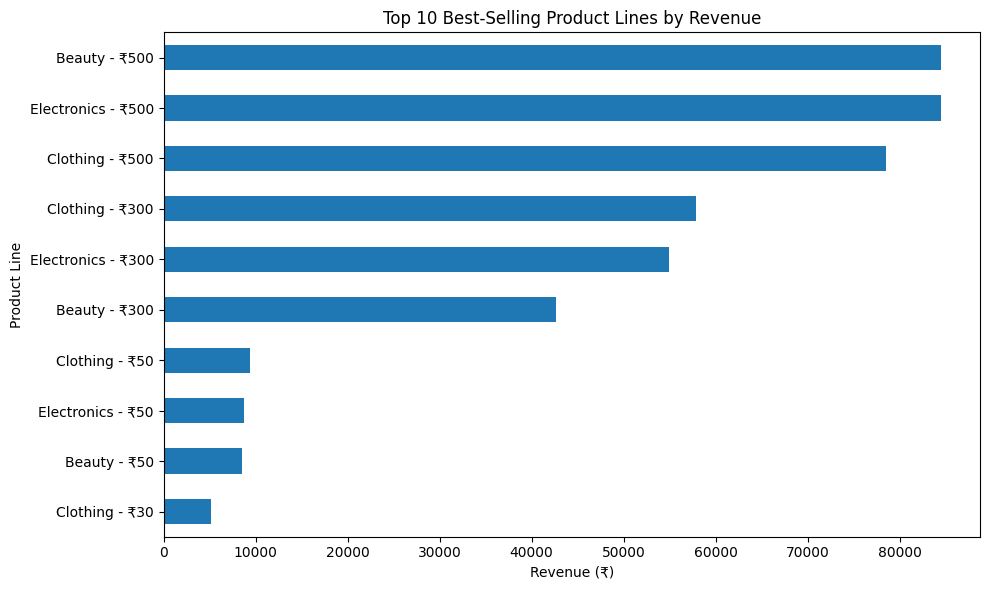

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
top_products['Total_Revenue'].sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Best-Selling Product Lines by Revenue')
ax.set_xlabel('Revenue (₹)')
plt.tight_layout()
plt.show()


Revenue is split almost evenly across the three categories (₹143K–157K each), so no single category dominates. Beauty sells the most units but at lower prices, while Clothing and Electronics earn similar revenue from fewer, higher-priced sales. The top 10 list shows a few high-priced Electronics and Clothing items bringing in a large share of revenue despite fewer transactions.

## 6. Correlation Heatmap

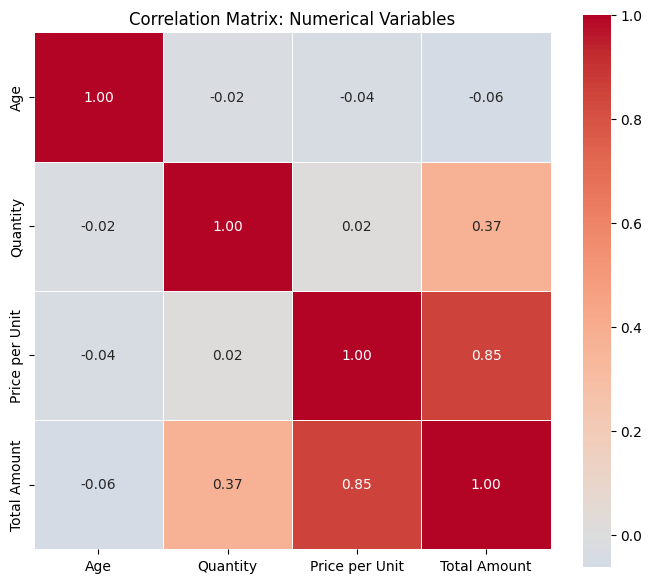

In [13]:
corr_matrix = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix: Numerical Variables')
plt.tight_layout()
plt.show()


`total_amount` is strongly linked to `price_per_unit` and `quantity`, which makes sense since it's calculated from them — and price has a slightly stronger effect than quantity. `age` barely correlates with anything, meaning spending habits don't really change with customer age, so age-based pricing or targeting probably wouldn't help revenue much.

## 7. Additional Insight: Age Group × Category Spending Patterns

This heatmap cross-tabulates **average spend per transaction** by age group and product category — revealing whether specific age segments over-index on specific categories, a pattern not visible from the aggregate charts above.

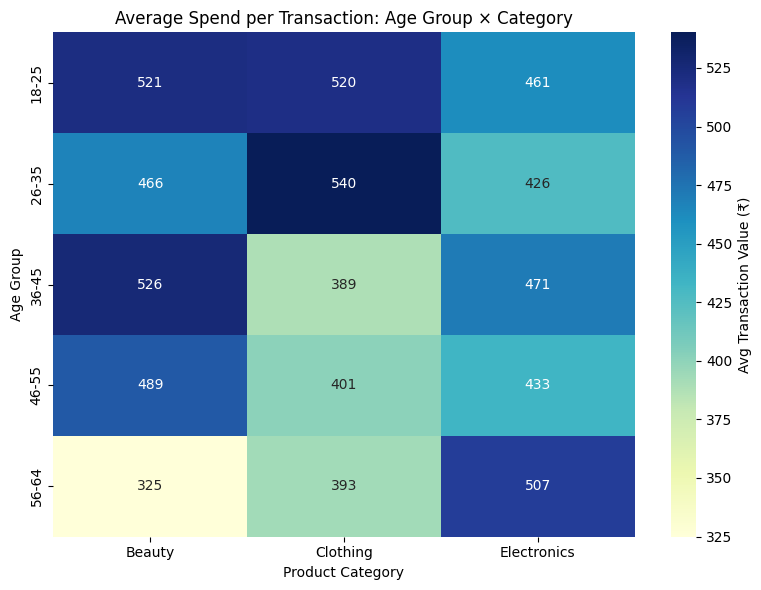

In [14]:
pivot_age_cat = df.pivot_table(values='Total Amount', index='Age Group',
                                  columns='Product Category', aggfunc='mean', observed=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_age_cat, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': 'Avg Transaction Value (₹)'})
ax.set_title('Average Spend per Transaction: Age Group × Category')
plt.tight_layout()
plt.show()


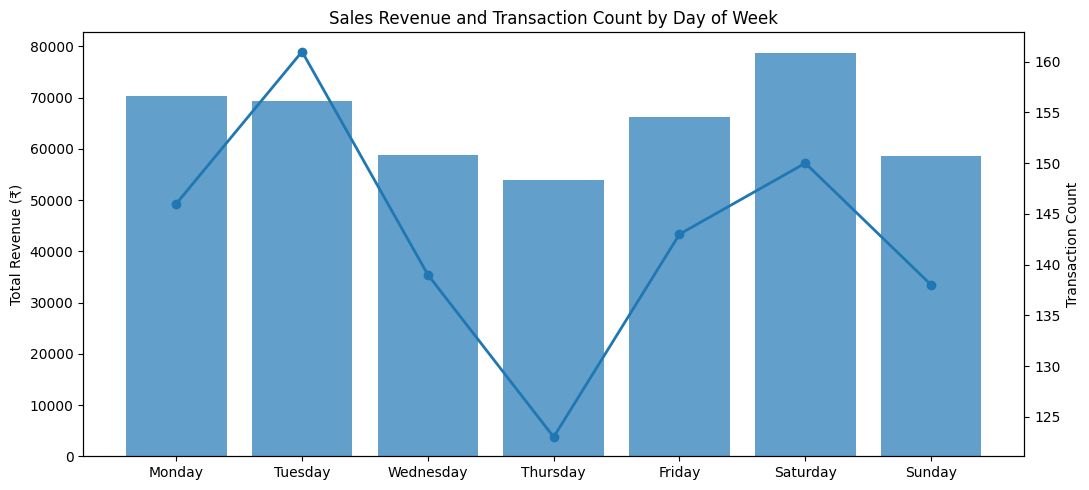

In [15]:
# Also examine day-of-week purchasing patterns
df['Day of Week'] = df['Date'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df.groupby('Day of Week')['Total Amount'].agg(['sum', 'count']).reindex(dow_order)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(dow_sales.index, dow_sales['sum'], alpha=0.7, label='Total Revenue')
ax1.set_ylabel('Total Revenue (₹)')
ax1.set_title('Sales Revenue and Transaction Count by Day of Week')

ax2 = ax1.twinx()
ax2.plot(dow_sales.index, dow_sales['count'], marker='o', linewidth=2, label='Transaction Count')
ax2.set_ylabel('Transaction Count')
ax2.grid(False)

plt.tight_layout()
plt.show()


**Observation:** The age × category heatmap shows whether certain age groups spend more on specific categories — a pattern you wouldn't catch by looking at age or category alone, and useful for targeted promotions. The day-of-week chart shows sales are spread pretty evenly across the week rather than peaking on weekends, which is a bit surprising for retail — weekend-only promotions might be missing a lot of demand.

## 8. Conclusion & Business Recommendations

Three takeaways from this analysis:

1. **Bundle Beauty with Clothing/Electronics.** Beauty sells the most units but at lower prices, while Clothing and Electronics earn similar revenue from fewer, pricier sales. Bundling a high-volume Beauty item with a high-margin Clothing/Electronics item could raise average order value without discounting the higher-margin categories.

2. **Target by age + category, not age alone.** Age barely correlates with spending, so generic age-based discounts likely won't help. Instead, use the age × category heatmap to find which age groups already spend more in which categories, and run offers aimed at those specific combinations.

3. **Don't limit promotions to weekends.** Sales are spread evenly across the week, not weekend-heavy, so weekend-only campaigns are probably missing a lot of demand. Shifting some promotional budget to weekdays (e.g., a Tuesday–Thursday sale) could capture that.

